In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from matplotlib.colors import LogNorm, Normalize
from sklearn.metrics import r2_score
import statsmodels.formula.api as smf


In [2]:
def data_prep_melt(feature_path='data/Table_EV6.tsv',ptr_path='data/Table_EV3.tsv',orig_features=True):
    features = pd.read_csv(feature_path, sep='\t')

    if orig_features:
        features = features.iloc[:, 0:208]

    ptr = pd.read_csv(ptr_path, sep='\t')
    ptr = ptr[[col for col in ptr.columns if "mRNA" not in col]]
    ptr = ptr[[col for col in ptr.columns if "protein" not in col]]

    id_vars = ptr.columns[:4]
    value_vars = ptr.columns[4:] 
    ptr_long = ptr.melt(id_vars=id_vars, value_vars=value_vars, 
                var_name='tissue', value_name='PTR')
    ptr_long['tissue'] = ptr_long['tissue'].str.replace('_PTR', '', regex=False)
    ptr_long['PTR'] = pd.to_numeric(ptr_long['PTR'], errors='coerce')
    ptr_long = ptr_long.dropna(subset=['PTR'])

    features = features[features.columns.drop(['GeneName', 'EnsemblTranscriptID', 'EnsemblProteinID'])]
    ptr_long = ptr_long[ptr_long.columns.drop(['GeneName', 'EnsemblTranscriptID', 'EnsemblProteinID'])]

    return features, ptr_long

features, ptr_long = data_prep_melt()

In [3]:
def mixed_model(features, ptr_long):

    merged = ptr_long.merge(features, on='EnsemblGeneID')
    merged['tissue'] = merged['tissue'].astype('category')
    merged.columns = merged.columns.str.replace('.', '_', regex=False)

    print('Maximum value for feature stop_P3.C: ' + str(np.max(merged['stop_P3_C'])) + 
          '. Feature will be removed from the model.')

    features = features.columns.drop(['EnsemblGeneID','stop_P3.C'])
    features = features.str.replace('.', '_', regex=False)


    fixed_effects = 'C(tissue) + ' + ' + '.join(features) 

    formula = f'PTR ~ {fixed_effects}'

    kf = KFold(n_splits=10, shuffle=True)

    predicted_ptr = np.zeros(len(merged))
    coefs_list = []
    intercepts_list = []

    for train_idx, test_idx in kf.split(merged):
        
        merged_train = merged.iloc[train_idx]
        model = smf.mixedlm(formula, data=merged_train, groups=merged_train['EnsemblGeneID'])

        result = model.fit()

        predicted_ptr[test_idx] = result.predict(merged.iloc[test_idx])
        coefs_list.append(result.params)
        intercepts_list.append(result.params.get('Intercept', np.nan))
    
    ptr_long['predicted_PTR'] = predicted_ptr

    return coefs_list, intercepts_list, ptr_long


coefs_list, intercepts_list, ptr_pred = mixed_model(features, ptr_long)

Maximum value for feature stop_P3.C: 0. Feature will be removed from the model.


KeyboardInterrupt: 

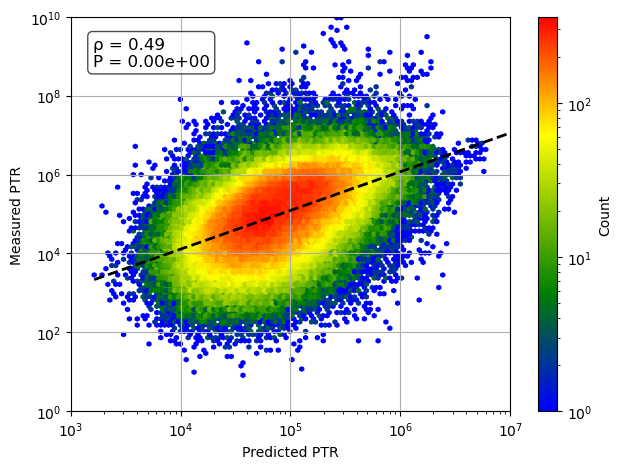

In [45]:
def hexbin(ptr_pred):

    # predf = pred.flatten()
    # ptrf = ptr.values.flatten()
    ptr_long = ptr_pred['PTR']
    predicted_ptr = ptr_pred['predicted_PTR']
    rho, pval = spearmanr(predicted_ptr, ptr_long)

    pred_exp = 10**predicted_ptr
    
    ptr_exp = 10**ptr_long

    colors = [
        (0.0, "blue"),
        (0.3, "green"),
        (0.7, "yellow"),
        (1  , "red"),
    ]

    custom_cmap = LinearSegmentedColormap.from_list("blue_yellow_red", colors)

    hb =plt.hexbin(pred_exp, ptr_exp,gridsize=100, 
            xscale = 'log',yscale = 'log',cmap=custom_cmap, bins = 'log' ,mincnt=1  )


    m, b = np.polyfit(predicted_ptr, ptr_long, 1)
    x_fit = np.linspace(predicted_ptr.min(), ptr_long.max(), 100)
    y_fit = m * x_fit + b
    
    cb = plt.colorbar(hb)
    cb.set_label('Count')
    plt.plot(10**x_fit, 10**y_fit, color='black', linestyle='--', linewidth=2, label='Fit line')
    plt.xlim(1e3, 1e7)
    plt.ylim(1, 1e10)
    plt.text(
        0.05, 0.95, f'ρ = {float(rho):.2f}\nP = {float(pval):.2e}',
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
    plt.xlabel('Predicted PTR')
    plt.ylabel('Measured PTR')
    plt.grid()
    plt.tight_layout()
    plt.show()

hexbin(ptr_pred)

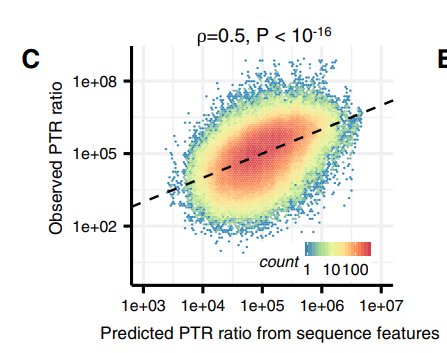

In [54]:
def r2(features, ptr_pred):

    feat_array = features.values

    r2_scores = []
    for tissue in ptr_pred["tissue"].unique():
        
        observed = ptr_pred[ptr_pred['tissue'] == tissue]['PTR']
        predicted = ptr_pred[ptr_pred['tissue'] == tissue]['predicted_PTR']
        scores = r2_score(observed, predicted)
        r2_scores.append(scores)

    r2_scores = np.array(r2_scores) 
    median_r2 = np.median(r2_scores)

    print('Median R² across all tissues: ' + str(median_r2))
    print(pd.DataFrame({
        'Tissue': ptr_pred["tissue"].unique(),
        '(Mean) R²': r2_scores
    }))

r2(features, ptr_pred)

Median R² across all tissues: 0.22760131541654283
            Tissue  (Mean) R²
0          Adrenal   0.254768
1       Appendices   0.180516
2            Brain   0.260149
3            Colon   0.189387
4         Duodenum   0.236814
5      Endometrium   0.228912
6        Esophagus   0.212134
7    Fallopiantube   0.235097
8              Fat   0.193293
9      Gallbladder   0.224754
10           Heart   0.188040
11          Kidney   0.227965
12           Liver   0.217983
13            Lung   0.208294
14       Lymphnode   0.245821
15           Ovary   0.192467
16        Pancreas   0.175671
17        Placenta   0.225014
18        Prostate   0.206632
19          Rectum   0.231289
20   Salivarygland   0.249342
21  Smallintestine   0.237600
22    Smoothmuscle   0.227601
23          Spleen   0.225810
24         Stomach   0.246546
25          Testis   0.245511
26         Thyroid   0.239360
27          Tonsil   0.246691
28  Urinarybladder   0.211977


In [ ]:
#earlier version of functions implementing simple linear regression

def data_prep(feature_path='data/Table_EV6.tsv',ptr_path='data/Table_EV3.tsv',orig_features=True):
    features = pd.read_csv(feature_path, sep='\t')

    features = features.iloc[:, 4:]
    if orig_features:
        features = features.iloc[:, 0:204]

    ptr = pd.read_csv(ptr_path, sep='\t')
    ptr = ptr[[col for col in ptr.columns if "PTR" in col]]

    ptr = ptr.apply(pd.to_numeric, errors='coerce')
    valid_idx = ptr.notna().all(axis=1)
    ptr = ptr[valid_idx]
    features = features.loc[valid_idx]
    return features, ptr

features, ptr = data_prep()
print(features.shape, ptr.shape)
print(type(features), type(ptr))

def linear_regression(features, ptr):
    model = LinearRegression()
    kf = KFold(n_splits=10, shuffle=True)
    
    pred = np.zeros_like(ptr, dtype=float)  
    coefs_list = []
    intercepts_list = []

    for train_idx, test_idx in kf.split(features):
        feat_train, feat_test = features.iloc[train_idx], features.iloc[test_idx]
        ptr_train = ptr.iloc[train_idx]

        model.fit(feat_train, ptr_train)

        pred[test_idx] = model.predict(feat_test)
        coefs_list.append(model.coef_)
        intercepts_list.append(model.intercept_)
        

    return coefs_list, intercepts_list, pred

coefs, intercepts, pred = linear_regression(features, ptr)

def coef_heatmap(coefs, features, ptr):
    avg_coefs = np.mean(np.array(coefs), axis=0)
    coefs_df = pd.DataFrame(avg_coefs.T, index=features.columns, columns=list(ptr.columns))
    plt.figure(figsize=(20, 40))  # Increase size (width, height) as needed

    sns.heatmap(
        coefs_df,
        fmt=".2e",                  # scientific notation for tiny values
        cmap="seismic",             # strong diverging color map
        center=0,                   # ensures 0 is the neutral color
        vmin=-0.25, vmax=0.25,      # manually set color range to highlight small differences
        cbar_kws={'label': 'Coefficient Value'}
    )

    plt.title("Coefs per Feature per Tissue", fontsize=16)
    plt.xlabel("Tissue", fontsize=14)
    plt.ylabel("Coef", fontsize=14)

    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=9)

    plt.tight_layout()
    plt.show()


coef_heatmap(coefs, features, ptr)